# mDLAG Synthetic Demo

This notebook builds a synthetic multigroup delayed latent model, fits mDLAG, and compares the recovered structure to ground truth.

Use `QUICK_MODE=True` for a fast run, or `QUICK_MODE=False` for a larger example.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from latents.mdlag.core import mDLAGModel
from latents.mdlag.descriptive_stats import predictive_performance
from latents.mdlag.gp.fit_config import GPFitConfig
from latents.mdlag.gp.gp_model import mDLAGGP
from latents.mdlag.gp.kernels.rbf.rbf_kernel import RBFKernel
from latents.mdlag.simulation import generate_latents, generate_observations
from latents.observation_model.probabilistic import HyperPriorParams, ObsParamsARD
from latents.plotting import find_optimal_permutation, hinton
from latents.state_model.latents import StateParamsDelayed

In [2]:
QUICK_MODE = True  # Set to False for a fuller run

if QUICK_MODE:
    T = 12
    x_dim = 4
    N = 100
    MAX_ITER = 400
else:
    T = 25
    x_dim = 7
    N = 100
    MAX_ITER = 3000

BIN_WIDTH = 20
SEED = 42

## Build the synthetic ground-truth model

In [3]:
rng = np.random.RandomState(SEED)

y_dims = np.array([10, 10, 10])
num_groups = len(y_dims)

snr = 1.0 * np.ones(len(y_dims))

# Hyperpriors with a dynamic sparsity pattern sized by x_dim
MAG = 100.0
sparsity_pattern = np.full((3, x_dim), np.inf)
shared = min(3, x_dim)
sparsity_pattern[:, :shared] = 1
for i in range(shared, x_dim):
    sparsity_pattern[i % 3, i] = 1

hyper_priors_generate = HyperPriorParams(
    a_alpha=MAG * sparsity_pattern,
    b_alpha=MAG * np.ones_like(sparsity_pattern),
    a_phi=1.0,
    b_phi=1.0,
    d_beta=1.0,
)

# GP timescales
_tau_base = np.array([30, 80, 50, 120, 100, 40, 70])
if x_dim <= len(_tau_base):
    tau = _tau_base[:x_dim]
else:
    reps = int(np.ceil(x_dim / len(_tau_base)))
    tau = np.tile(_tau_base, reps)[:x_dim]

eps = 1e-3 * np.ones(x_dim)

# Inter-group delays
D = np.zeros((3, x_dim))
_pattern_g2 = [15, -30, 0]
_pattern_g3 = [30, 0, -25]
for i in range(x_dim):
    D[1, i] = _pattern_g2[i % len(_pattern_g2)]
    D[2, i] = _pattern_g3[i % len(_pattern_g3)]
D = D / BIN_WIDTH

gamma = (BIN_WIDTH / tau) ** 2

obs_params_true = ObsParamsARD.generate(y_dims, x_dim, hyper_priors_generate, snr, rng)
gp_true = mDLAGGP(gamma=gamma, delays=D, eps=eps, kernel=RBFKernel())
state_params_true = StateParamsDelayed(x_dim, len(y_dims), T)

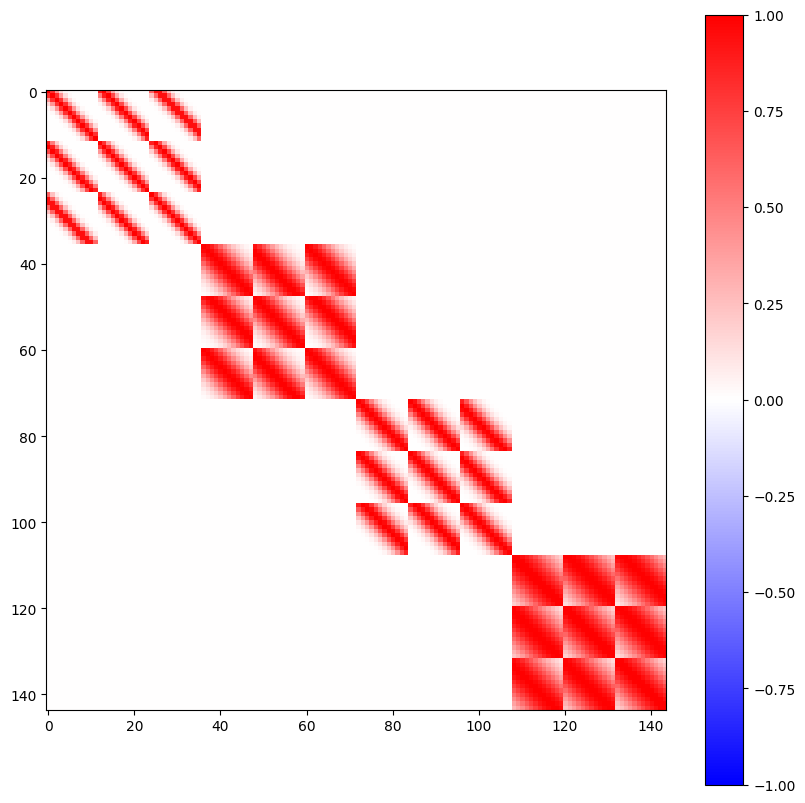

In [4]:
K_big = gp_true.build_kernel_matrix(T, return_tensor=False, order="C")

plt.figure(figsize=(10, 10))
plt.imshow(
    K_big,
    cmap="bwr",
    vmin=-np.abs(K_big).max(),
    vmax=np.abs(K_big).max(),
)
plt.colorbar()
plt.show()

## Generate synthetic data

In [5]:
X_true = generate_latents(gp_true, T=T, N=N, rng=rng)
Y = generate_observations(X_true, obs_params_true, rng)

print(f"Observed data shape: {Y.data.shape}")
print(f"Group dimensions:    {y_dims.tolist()}")
print(f"Latent dim (true):   {x_dim}")

Observed data shape: (30, 12, 100)
Group dimensions:    [10, 10, 10]
Latent dim (true):   4


### Ground-truth latent trajectories

Inspect a single trial of the simulated latent trajectories across all groups.

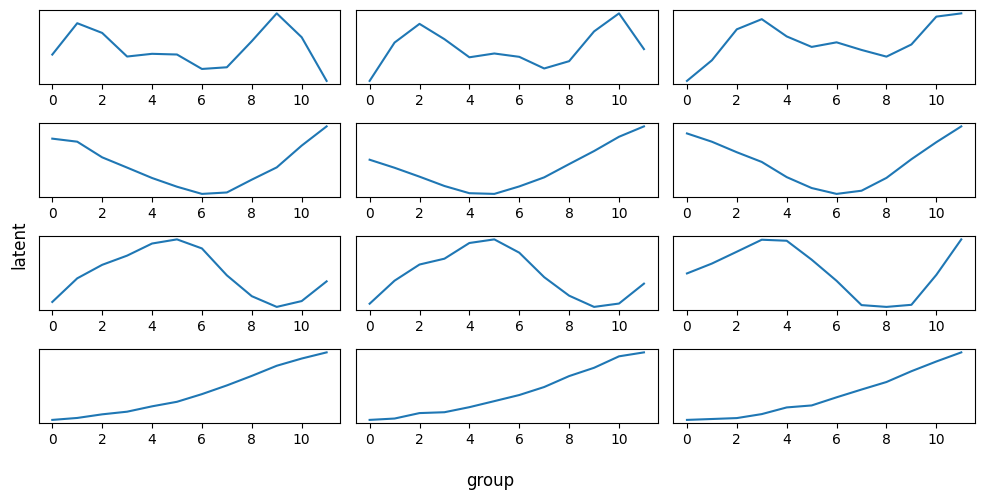

In [6]:
trial_idx = 0
fig, ax = plt.subplots(x_dim, num_groups, figsize=(10, 5))

for i in range(X_true.shape[0]):
    for j in range(X_true.shape[1]):
        ax[i, j].plot(X_true[i, j, :, trial_idx])

plt.setp(ax, yticks=[])
fig.supxlabel("group")
fig.supylabel("latent")
plt.tight_layout()
plt.show()

## Fit mDLAG

In [7]:
model = mDLAGModel()

gp_fit_config = GPFitConfig(
    max_iter=20,
    tol=1e-5,
    grad_mode="autodiff",
    verbose=False,
)

model.fit_args.set_args(
    gp_fit_config=gp_fit_config,
    hyper_priors=HyperPriorParams(),
    fit_tol=1e-7,
    max_iter=MAX_ITER,
    verbose=True,
    random_seed=SEED,
    prune_X=True,
    prune_tol=1e-7,
    save_X_cov=False,
    save_C_cov=False,
    save_fit_progress=True,
)

x_dim_init = x_dim if QUICK_MODE else 10
model.init(Y, x_dim_init=x_dim_init, bin_width=BIN_WIDTH, kernel=RBFKernel(), eps=1e-3)

model.fit(Y)

Iteration 400 of 400        lb -65825.08820094545
Fitting stopped after max_iter (400) was reached.


## Inspect the fitted model

### Training diagnostics

Converged: False
Decreasing lower bound: False
Private variance floor: False
Latent dimensions removed: 0


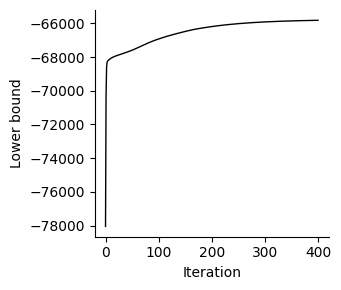

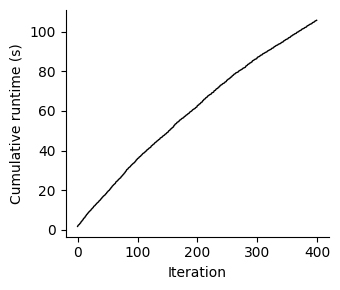

In [8]:
model.flags.display()

model.tracker.plot_lb()
model.tracker.plot_runtime()

### Predictive performance

In [9]:
R2, MSE = predictive_performance(Y, model.params)
print(f"Leave-group-out R\u00b2: {R2:.4f}")
print(f"Leave-group-out MSE: {MSE:.4f}")

Leave-group-out R²: 0.3760
Leave-group-out MSE: 4.1731


## Parameter recovery

### Loading matrix

Align latent order and sign before comparing the fitted loading matrix with the ground truth.

In [ ]:
C_estimated = model.params.obs_params.C.mean
C_true = obs_params_true.C.mean

permutation, sign_flips, cost = find_optimal_permutation(C_estimated, C_true)
aligned_C = C_estimated[:, permutation] * sign_flips
print(f"Alignment cost: {cost:.4f}")

Exploring all 24 possible permutations...
Alignment cost: 5.1544


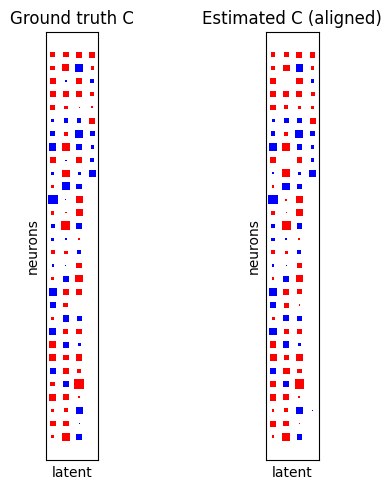

In [11]:
plt.figure(figsize=(6, 5))

plt.subplot(1, 2, 1)
plt.title("Ground truth C")
hinton(obs_params_true.C.mean)
plt.xlabel("latent")
plt.ylabel("neurons")

plt.subplot(1, 2, 2)
plt.title("Estimated C (aligned)")
hinton(aligned_C)
plt.xlabel("latent")
plt.ylabel("neurons")

plt.tight_layout()
plt.show()

### ARD structure

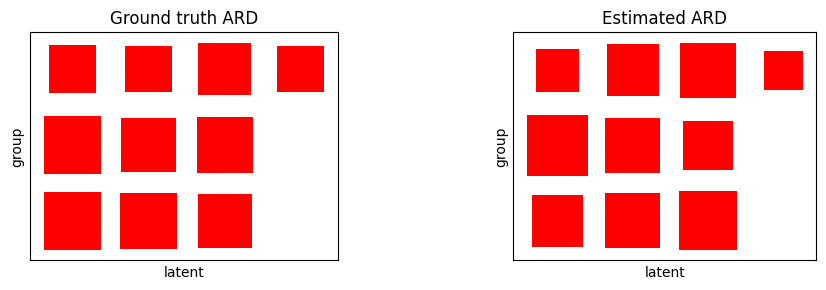

In [12]:
alpha_inv_true = 1 / obs_params_true.alpha.mean
alpha_inv_rel_true = alpha_inv_true / np.sum(alpha_inv_true, axis=1, keepdims=True)

alpha_inv_est = 1 / model.params.obs_params.alpha.mean[:, permutation]
alpha_inv_rel_est = alpha_inv_est / np.sum(alpha_inv_est, axis=1, keepdims=True)

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.title("Ground truth ARD")
hinton(alpha_inv_rel_true)
plt.xlabel("latent")
plt.ylabel("group")

plt.subplot(1, 2, 2)
plt.title("Estimated ARD")
hinton(alpha_inv_rel_est)
plt.xlabel("latent")
plt.ylabel("group")

plt.tight_layout()
plt.show()

### Latent trajectories

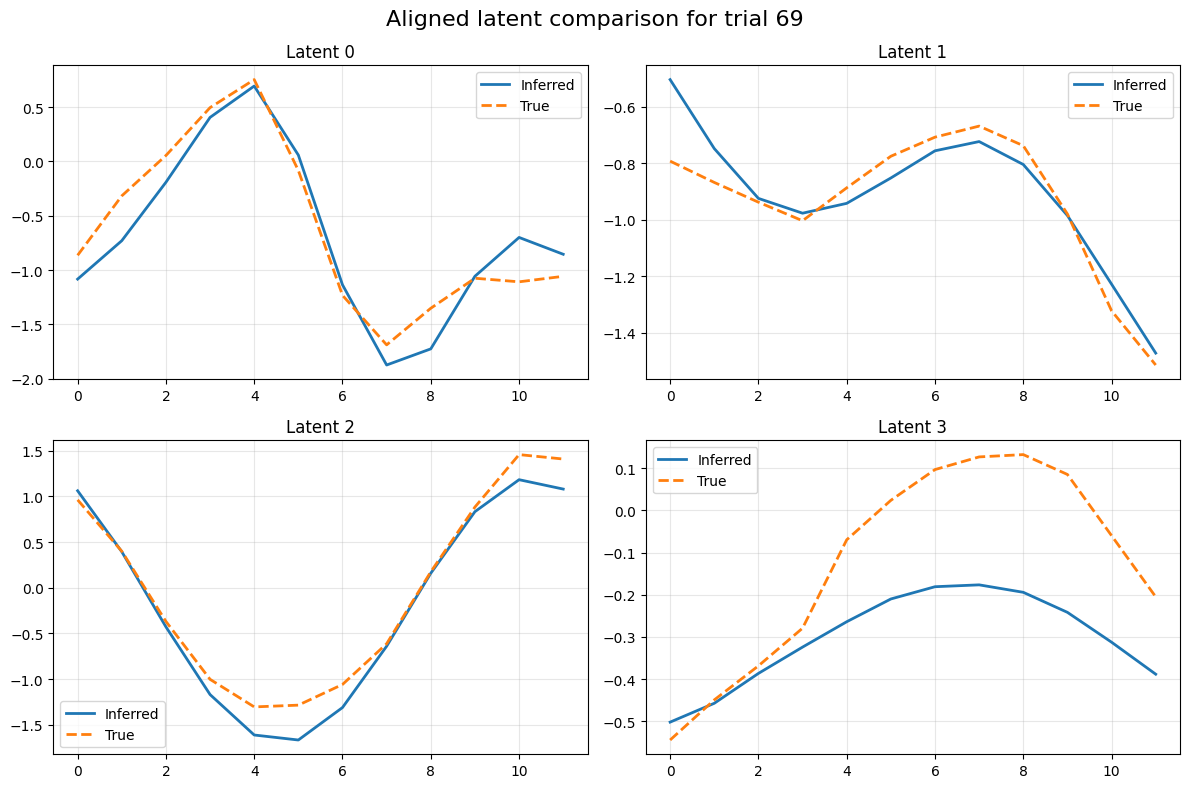

In [13]:
comparison_trial_idx = rng.randint(N)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"Aligned latent comparison for trial {comparison_trial_idx}", fontsize=16)

for i in range(min(4, model.params.state_params.x_dim)):
    row, col = i // 2, i % 2
    aligned_idx = permutation[i]
    sign_flip = sign_flips[i]
    axes[row, col].plot(
        model.params.state_params.X.mean[aligned_idx, 0, :, comparison_trial_idx] * sign_flip,
        label="Inferred",
        linewidth=2,
    )
    axes[row, col].plot(
        X_true[i, 0, :, comparison_trial_idx],
        "--",
        label="True",
        linewidth=2,
    )
    axes[row, col].set_title(f"Latent {i}")
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Delay-timescale relationships

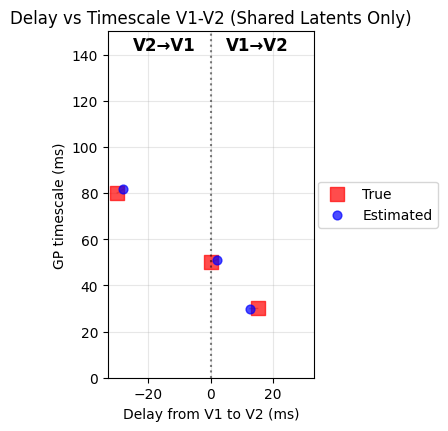

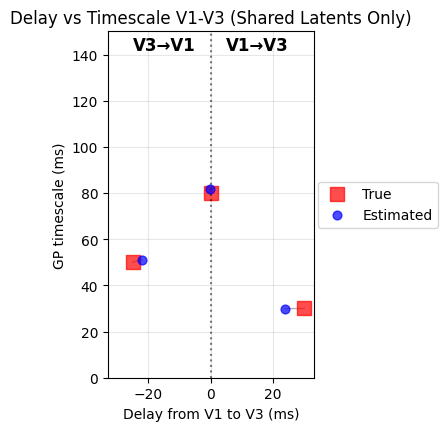

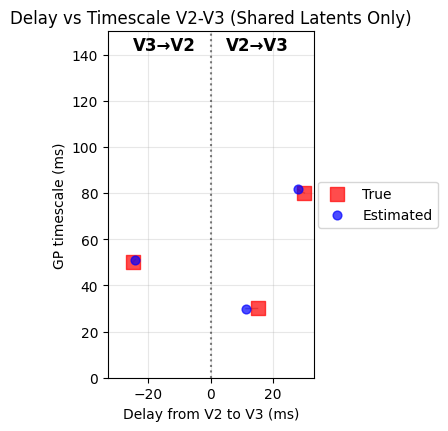

In [14]:
D_estimated = model.params.gp.params.delays[:, permutation] * BIN_WIDTH
D_true = gp_true.params.delays * BIN_WIDTH
Timescale_true = BIN_WIDTH / np.sqrt(gp_true.params.gamma)
Timescale_estimated = BIN_WIDTH / np.sqrt(model.params.gp.params.gamma[permutation])
fraction_shared_variance_true = alpha_inv_rel_true

group_pairs = [(0, 1, "V1-V2"), (0, 2, "V1-V3"), (1, 2, "V2-V3")]

for g1, g2, title in group_pairs:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))

    shared_latents = [
        latent for latent in range(x_dim)
        if fraction_shared_variance_true[g1, latent] > 0.02
        and fraction_shared_variance_true[g2, latent] > 0.02
    ]

    if len(shared_latents) > 0:
        shared_perm = np.array(shared_latents)

        timescales_est = Timescale_estimated[shared_perm]
        delays_ms_est = D_estimated[g2, shared_perm] - D_estimated[g1, shared_perm]

        timescales_true = Timescale_true[shared_perm]
        delays_ms_true = D_true[g2, shared_perm] - D_true[g1, shared_perm]

        ax.scatter(
            delays_ms_true, timescales_true,
            c="red", s=100, alpha=0.7, label="True", marker="s", zorder=2,
        )
        ax.scatter(
            delays_ms_est, timescales_est,
            c="blue", s=40, alpha=0.7, label="Estimated", marker="o", zorder=3,
        )

        for i in range(len(shared_latents)):
            ax.plot(
                [delays_ms_est[i], delays_ms_true[i]],
                [timescales_est[i], timescales_true[i]],
                "k-", alpha=0.3, linewidth=1, zorder=1,
            )

        max_delay = max(np.abs(delays_ms_est).max(), np.abs(delays_ms_true).max())
        ax.set_xlim(-max_delay * 1.1, max_delay * 1.1)
        ax.set_ylim(0, 150)
        ax.axvline(x=0, color="k", linestyle=":", alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

        g1_name, g2_name = title.split("-")
        ax.text(max_delay * 0.5, 140, f"{g1_name}\u2192{g2_name}",
                ha="center", va="bottom", fontsize=12, fontweight="bold")
        ax.text(-max_delay * 0.5, 140, f"{g2_name}\u2192{g1_name}",
                ha="center", va="bottom", fontsize=12, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 0.8, 1])
    else:
        ax.text(0.5, 0.5, f"No shared latents between groups {g1+1} and {g2+1}",
                ha="center", va="center", transform=ax.transAxes, fontsize=12)
        plt.tight_layout()

    ax.set_xlabel(f"Delay from {title.split('-')[0]} to {title.split('-')[1]} (ms)")
    ax.set_ylabel("GP timescale (ms)")
    ax.set_title(f"Delay vs Timescale {title} (Shared Latents Only)")
    plt.show()

## Summary

The fitted model captures useful predictive structure and recovers the main qualitative patterns in the synthetic loading, ARD, delay, and timescale parameters.